<a href="https://colab.research.google.com/github/ForMyWebsite/Domus-Energeia/blob/main/VanillaPINNArchitecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VANILLA PINN - HEPATIC CIRCULATION
Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING DATASET
Loading -> /content/drive/MyDrive/hepatic_xpinn_dataset.npz

Dataset top-level keys:
  data                      shape=()
  K_gt                      shape=()
  source_terms_per_s        shape=()
  xpinn_subdomains          shape=()
  diagnostics               shape=()
  residual_floor            shape=()
  geometry                  shape=()
  provenance                shape=()
  steady                    shape=()
  continuity_form           shape=()
  coordinate_unit           shape=()
  velocity_unit             shape=()
  pressure_unit             shape=()
  pressure_reference        shape=()

Units:
  Coordinates : um
  Velocity    : m/s
  Pressure    : Pa
  K_gt        : 1.041591e-12 m²

Nested dataset keys:
  domains
  interfaces
  boundaries
  sparse_observations

LOADING DOMAINS

R

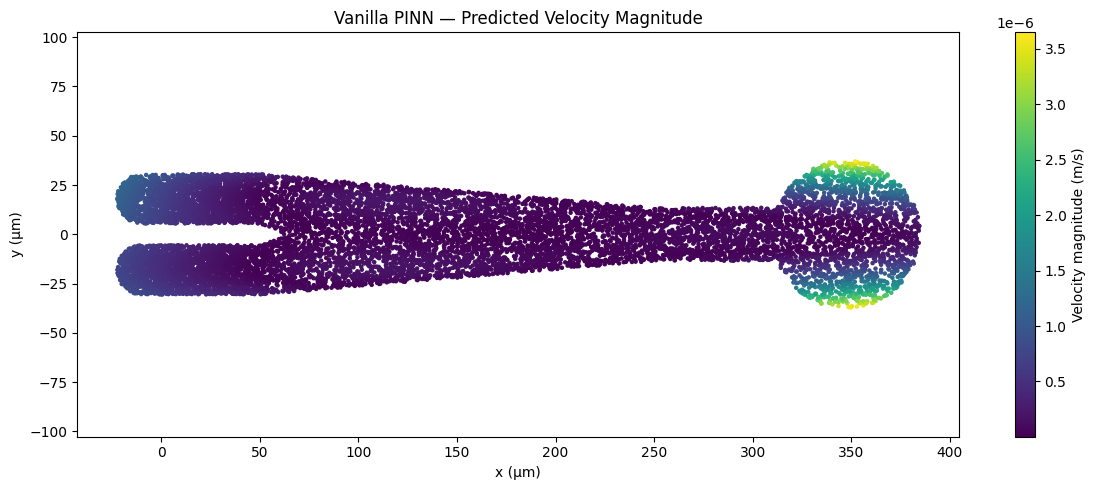

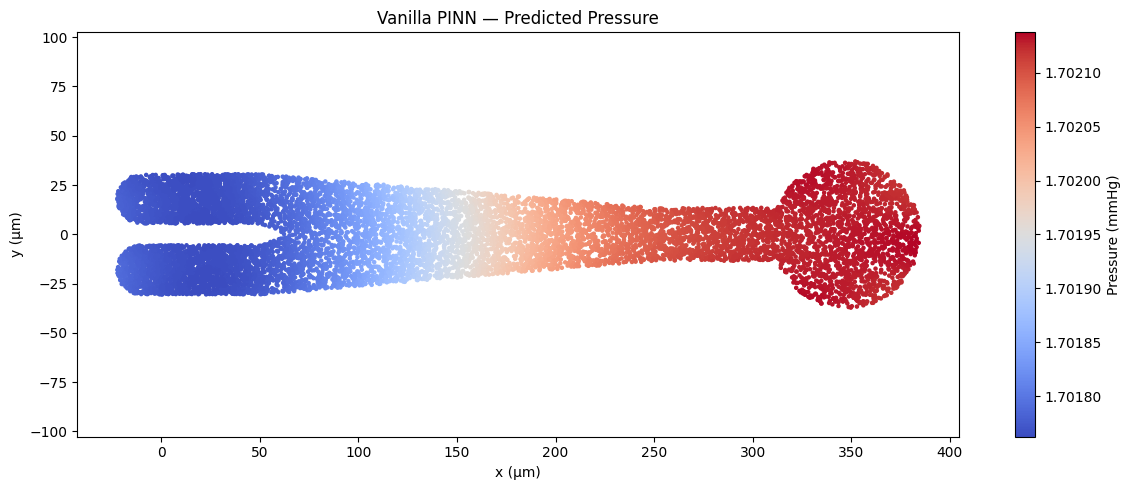

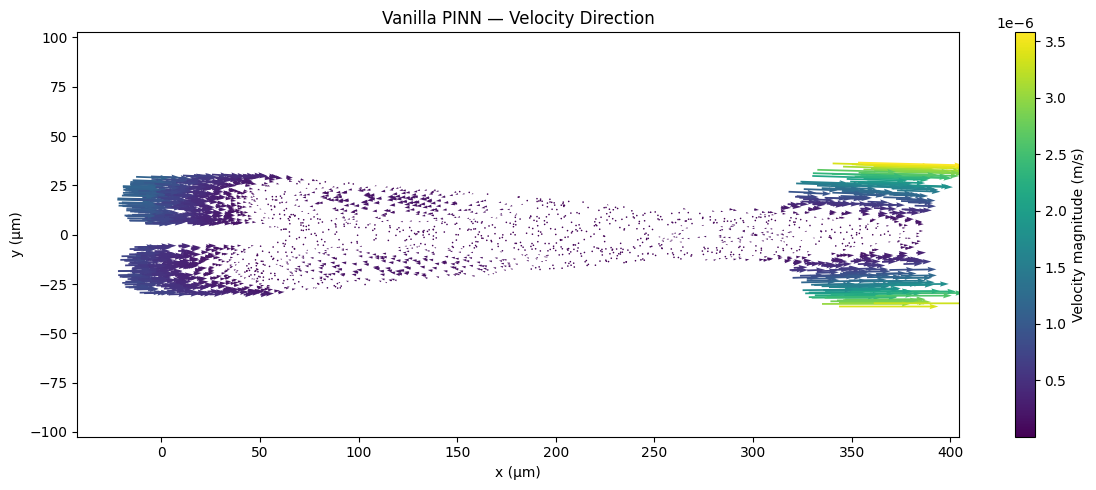

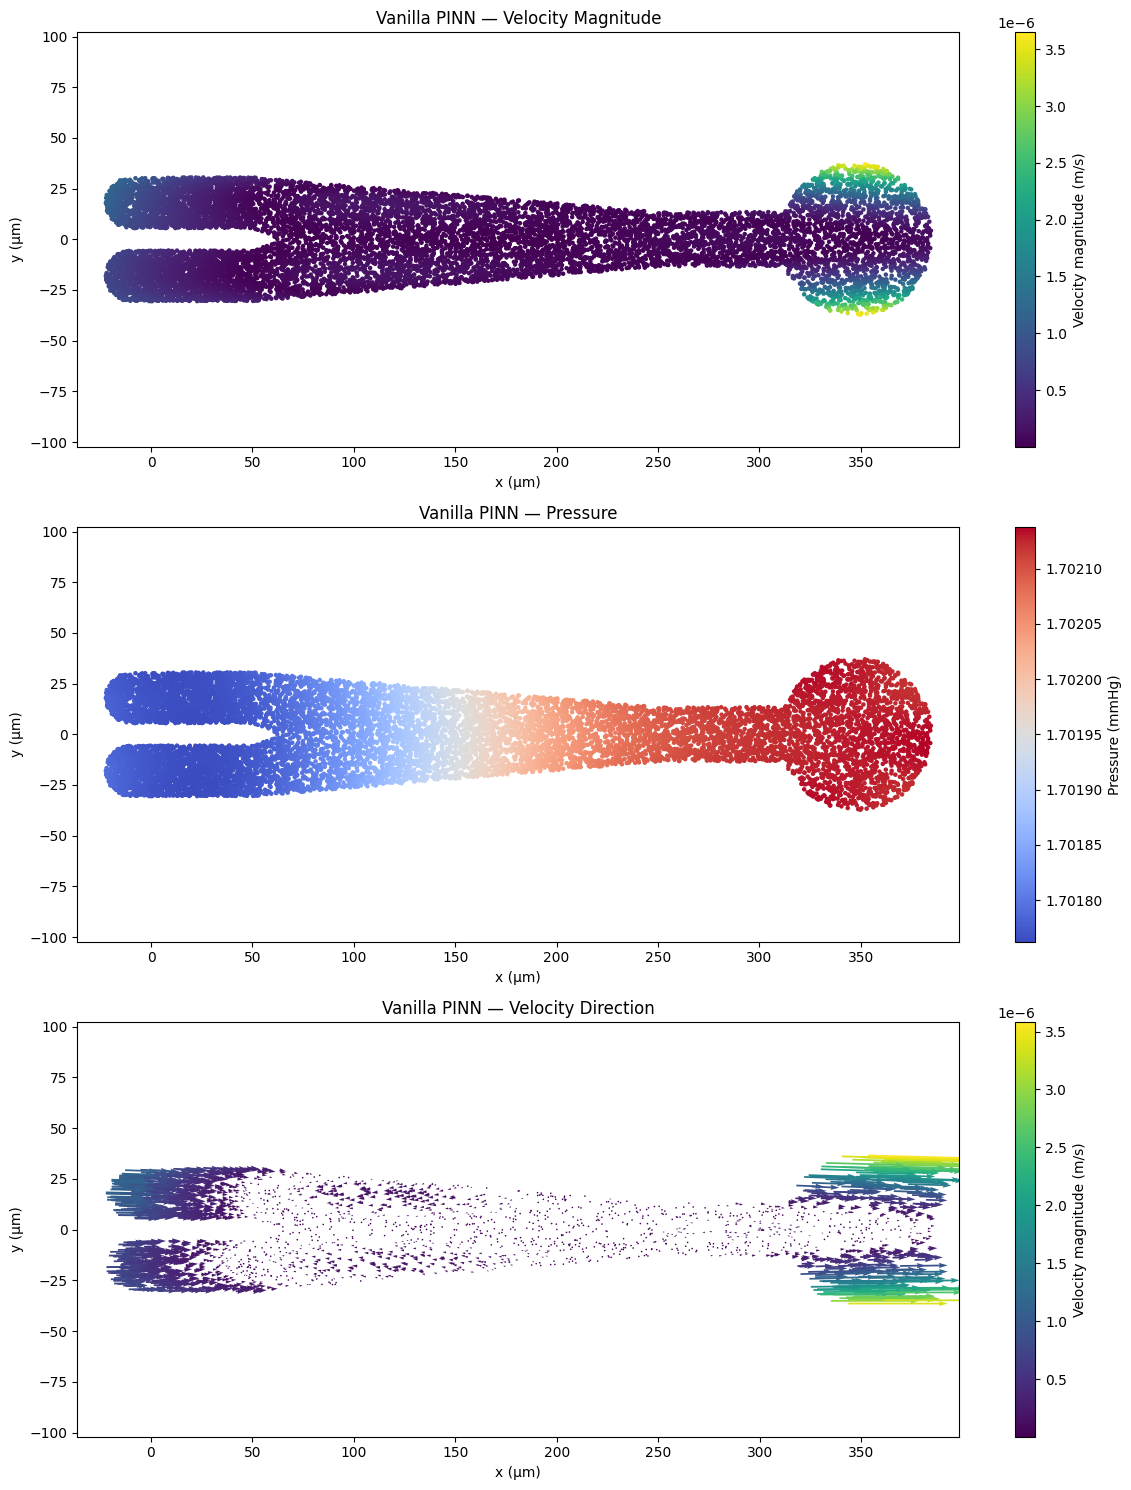

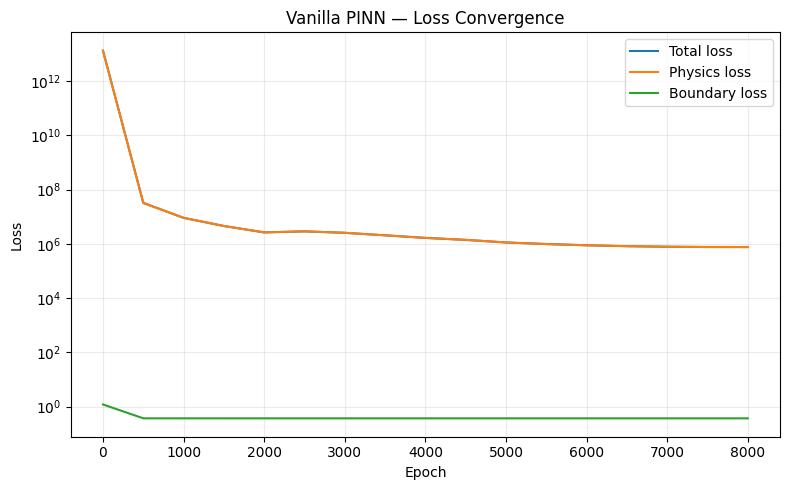


VALIDATION VISUALIZATION


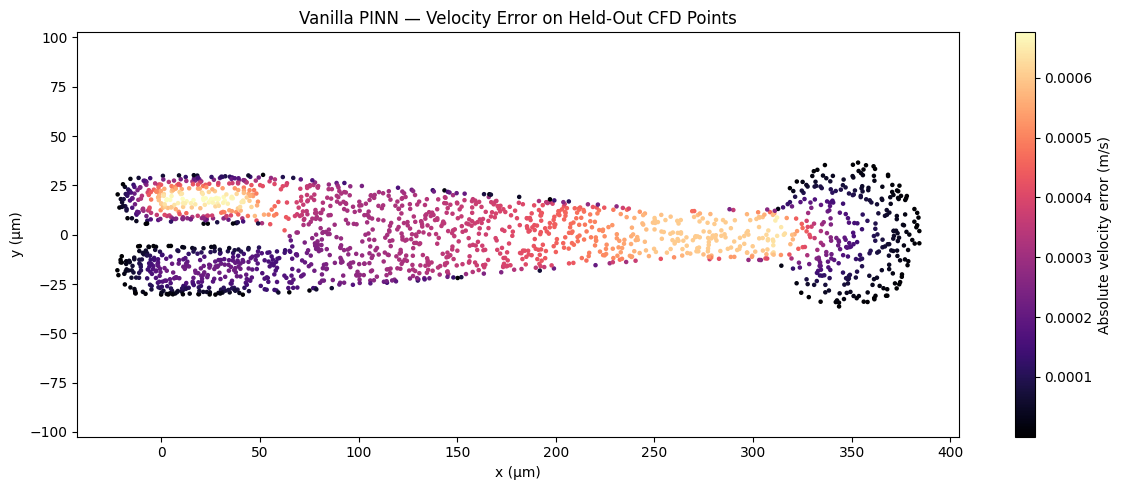

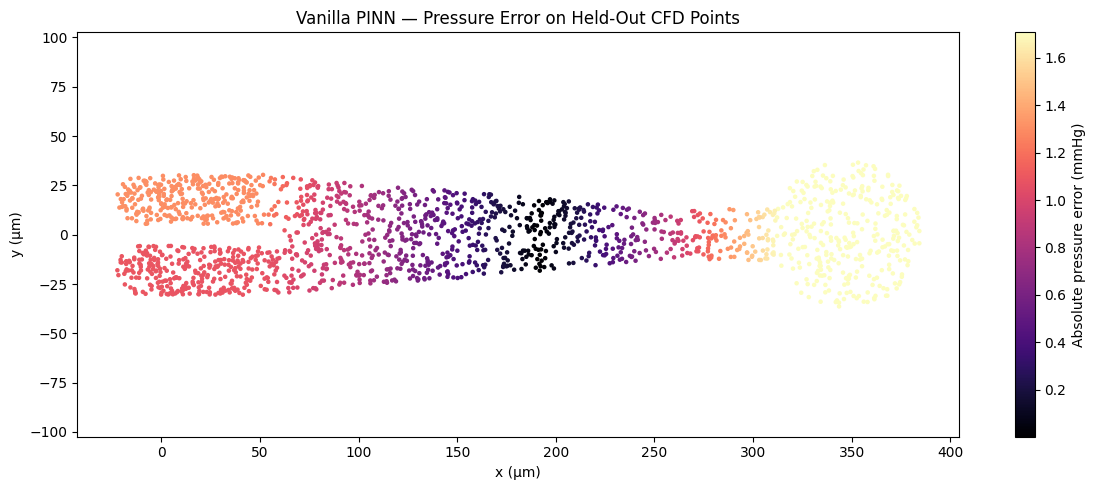


FILES SAVED
vanilla_pinn_final_checkpoint.pt
vanilla_pinn_velocity.png
vanilla_pinn_pressure.png
vanilla_pinn_velocity_direction.png
vanilla_pinn_three_panel.png
vanilla_pinn_loss_curve.png
vanilla_pinn_velocity_error.png
vanilla_pinn_pressure_error.png

DONE.


In [13]:
# =============================================================================
# VANILLA PINN FOR HEPATIC CIRCULATION
# =============================================================================
#
# ONE neural network for the entire hepatic junction.
#
# Inputs:
#       x, y, t
#
# Outputs:
#       U, V, P
#
# Physics:
#       Continuity
#       Incompressible Navier-Stokes in vessels
#       Brinkman/porous-flow term in sinusoid
#
# Domains:
#       artery
#       portal vein
#       sinusoid
#       central vein
#
# IMPORTANT:
#   This is ONE network.
#   There is NO XPINN domain decomposition.
#
# The CFD ground truth is NOT used as an interior training target.
# Ground truth is used AFTER training for validation/visualization.
#
# =============================================================================


import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn


# =============================================================================
# 0. SETTINGS
# =============================================================================

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("VANILLA PINN - HEPATIC CIRCULATION")
print("=" * 80)
print(f"Using device: {device}")


# =============================================================================
# 1. GOOGLE DRIVE
# =============================================================================

try:
    from google.colab import drive

    try:
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive mount message:", e)

except ImportError:
    print("Not running in Google Colab.")


# =============================================================================
# 2. FIND DATASET
# =============================================================================

SEARCH_ROOTS = [
    "/content",
    "/content/drive/MyDrive",
    "/mnt/user-data/uploads",
]


def find_dataset():

    candidates = []

    for root in SEARCH_ROOTS:

        if not os.path.exists(root):
            continue

        pattern = os.path.join(
            root,
            "**",
            "hepatic_xpinn_dataset*.npz"
        )

        candidates.extend(
            glob.glob(pattern, recursive=True)
        )

    # Remove duplicates
    candidates = list(dict.fromkeys(candidates))

    if len(candidates) == 0:
        raise FileNotFoundError(
            "\nCould not find hepatic_xpinn_dataset.npz\n"
            "Make sure it is in Google Drive/MyDrive."
        )

    # Most recently modified file
    candidates.sort(
        key=lambda p: os.path.getmtime(p),
        reverse=True
    )

    if len(candidates) > 1:
        print("\nMultiple datasets found:")
        for p in candidates:
            print("  ", p)

        print("\nUsing:")
        print("  ", candidates[0])

    return candidates[0]


npz_path = find_dataset()

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

print("Loading ->", npz_path)

raw = np.load(
    npz_path,
    allow_pickle=True
)


# =============================================================================
# 3. PRINT ACTUAL NPZ STRUCTURE
# =============================================================================

print("\nDataset top-level keys:")

for key in raw.files:
    try:
        value = raw[key]

        if hasattr(value, "shape"):
            print(f"  {key:25s} shape={value.shape}")

        else:
            print(f"  {key:25s} type={type(value)}")

    except Exception:
        print(" ", key)


# =============================================================================
# 4. READ METADATA
# =============================================================================

def read_npz_scalar(raw, key, default="unknown"):

    if key not in raw.files:
        return default

    value = raw[key]

    try:
        return str(value.item())

    except Exception:
        return str(value)


coord_unit = read_npz_scalar(
    raw,
    "coordinate_unit",
    "micrometers"
)

velocity_unit = read_npz_scalar(
    raw,
    "velocity_unit",
    "m/s"
)

pressure_unit = read_npz_scalar(
    raw,
    "pressure_unit",
    "Pa"
)


if "K_gt" in raw.files:
    K_gt = float(np.asarray(raw["K_gt"]).squeeze())

else:
    raise KeyError(
        "Dataset does not contain K_gt."
    )


print("\nUnits:")
print("  Coordinates :", coord_unit)
print("  Velocity    :", velocity_unit)
print("  Pressure    :", pressure_unit)
print(f"  K_gt        : {K_gt:.6e} m²")


# =============================================================================
# 5. LOAD NESTED DATA
# =============================================================================

if "data" not in raw.files:

    raise KeyError(
        "\nThis dataset does not contain raw['data'].\n"
        "The code expects the new nested hepatic dataset format."
    )


inner = raw["data"].item()

print("\nNested dataset keys:")

for key in inner.keys():
    print(" ", key)


domains = inner.get("domains", {})
interfaces = inner.get("interfaces", {})
boundaries = inner.get("boundaries", {})
sparse_obs = inner.get("sparse_observations", {})


# =============================================================================
# 6. DOMAIN NAME HANDLING
# =============================================================================
#
# This is one of the major fixes.
#
# Your earlier code assumed that every key in domains was exactly:
#
#     artery
#     portal
#     sinusoid
#     central
#
# But your dataset may contain names such as:
#
#     portal_vein
#     central_vein
#     portal_sinusoid
#
# etc.
#
# We canonicalize them.
# =============================================================================


DOMAIN_NAME_TO_ID = {
    "artery": 0,
    "portal": 1,
    "sinusoid": 2,
    "central": 3,
}


def normalize_name(name):

    name = str(name).lower().strip()

    name = name.replace("-", "_")
    name = name.replace(" ", "_")

    return name


def canonical_domain(name):

    n = normalize_name(name)

    # Artery
    if (
        n == "artery"
        or "hepatic_artery" in n
    ):
        return "artery"

    # Portal vein
    if (
        n == "portal"
        or "portal_vein" in n
    ):
        return "portal"

    # Sinusoid
    if (
        n == "sinusoid"
        or "sinusoid_bed" in n
        or "sinusoids" in n
    ):
        return "sinusoid"

    # Central vein
    if (
        n == "central"
        or "central_vein" in n
    ):
        return "central"

    return None


# =============================================================================
# 7. EXTRACT X/Y/T
# =============================================================================

def extract_xyt(d, name="unknown"):

    # -----------------------------------------
    # Preferred format
    # -----------------------------------------

    if "xyt" in d:

        arr = np.asarray(
            d["xyt"],
            dtype=np.float64
        )

        if arr.ndim == 2 and arr.shape[1] >= 3:
            return arr[:, :3]


    # -----------------------------------------
    # Maybe coordinates are called coords
    # -----------------------------------------

    coordinate_key_candidates = [
        "coords",
        "coordinates",
        "points",
        "xy",
    ]

    coordinate_array = None

    for key in coordinate_key_candidates:

        if key in d:

            coordinate_array = np.asarray(
                d[key],
                dtype=np.float64
            )

            break


    # -----------------------------------------
    # Separate x/y/t arrays
    # -----------------------------------------

    if coordinate_array is None:

        if "x" in d and "y" in d:

            x = np.asarray(
                d["x"],
                dtype=np.float64
            ).reshape(-1)

            y = np.asarray(
                d["y"],
                dtype=np.float64
            ).reshape(-1)

            if "t" in d:

                t = np.asarray(
                    d["t"],
                    dtype=np.float64
                ).reshape(-1)

            else:

                t = np.zeros_like(x)

            return np.column_stack([
                x,
                y,
                t
            ])


    # -----------------------------------------
    # XY + T
    # -----------------------------------------

    if coordinate_array is not None:

        if coordinate_array.ndim != 2:

            raise ValueError(
                f"Coordinates for '{name}' are not 2-D."
            )

        if coordinate_array.shape[1] >= 3:

            return coordinate_array[:, :3]

        if coordinate_array.shape[1] == 2:

            if "t" in d:

                t = np.asarray(
                    d["t"],
                    dtype=np.float64
                ).reshape(-1)

                return np.column_stack([
                    coordinate_array[:, 0],
                    coordinate_array[:, 1],
                    t
                ])

            else:

                # Static dataset
                return np.column_stack([
                    coordinate_array[:, 0],
                    coordinate_array[:, 1],
                    np.zeros(len(coordinate_array))
                ])


    # -----------------------------------------
    # Nothing worked
    # -----------------------------------------

    try:
        available = list(d.keys())

    except Exception:
        available = [type(d)]

    raise KeyError(
        f"\nCould not find coordinates for '{name}'.\n"
        f"Available keys: {available}\n"
        f"Expected one of: xyt, coords, coordinates, points, xy, x+y+t"
    )


# =============================================================================
# 8. EXTRACT GROUND-TRUTH U/V/P
# =============================================================================

def extract_uvp(d, name="unknown"):

    # -----------------------------------------
    # Standard dataset format
    # -----------------------------------------

    if "u_gt" in d and "p_gt" in d:

        uv = np.asarray(
            d["u_gt"],
            dtype=np.float64
        )

        p = np.asarray(
            d["p_gt"],
            dtype=np.float64
        ).reshape(-1)

        # u_gt is expected to be [U,V]
        if uv.ndim == 2 and uv.shape[1] >= 2:

            return np.column_stack([
                uv[:, 0],
                uv[:, 1],
                p
            ])


    # -----------------------------------------
    # Maybe separate u/v/p
    # -----------------------------------------

    if (
        "u" in d
        and "v" in d
        and "p" in d
    ):

        u = np.asarray(
            d["u"],
            dtype=np.float64
        ).reshape(-1)

        v = np.asarray(
            d["v"],
            dtype=np.float64
        ).reshape(-1)

        p = np.asarray(
            d["p"],
            dtype=np.float64
        ).reshape(-1)

        return np.column_stack([
            u,
            v,
            p
        ])


    # -----------------------------------------
    # Maybe uvp directly
    # -----------------------------------------

    if "uvp" in d:

        arr = np.asarray(
            d["uvp"],
            dtype=np.float64
        )

        if arr.ndim == 2 and arr.shape[1] >= 3:
            return arr[:, :3]


    try:
        available = list(d.keys())

    except Exception:
        available = [type(d)]

    raise KeyError(
        f"\nCould not find U/V/P data for '{name}'.\n"
        f"Available keys: {available}\n"
        f"Expected u_gt + p_gt, u/v/p, or uvp."
    )


# =============================================================================
# 9. LOAD DOMAINS
# =============================================================================

print("\n" + "=" * 80)
print("LOADING DOMAINS")
print("=" * 80)

domain_xyt_list = []
domain_uvp_list = []
domain_id_list = []

print("\nRaw domain names found:")

for name in domains.keys():
    print("  ", name)


for name, d in domains.items():

    canonical = canonical_domain(name)

    # -----------------------------------------
    # Ignore anything that isn't one of the
    # four physical compartments.
    # -----------------------------------------

    if canonical is None:

        print(
            f"  Skipping non-domain entry: {name}"
        )

        continue

    try:

        xyt = extract_xyt(
            d,
            name
        )

        uvp = extract_uvp(
            d,
            name
        )

    except Exception as e:

        print(
            f"\nWARNING: Could not load domain '{name}'"
        )

        print(e)

        continue


    if len(xyt) != len(uvp):

        raise ValueError(
            f"Length mismatch in domain '{name}': "
            f"{len(xyt)} coordinates vs "
            f"{len(uvp)} U/V/P values."
        )


    domain_xyt_list.append(xyt)

    domain_uvp_list.append(uvp)

    domain_id_list.append(
        np.full(
            len(xyt),
            DOMAIN_NAME_TO_ID[canonical],
            dtype=np.int64
        )
    )


if len(domain_xyt_list) == 0:

    raise RuntimeError(
        "No valid physical domains were found."
    )


domain_xyt = np.concatenate(
    domain_xyt_list,
    axis=0
)

domain_uvp = np.concatenate(
    domain_uvp_list,
    axis=0
)

domain_id = np.concatenate(
    domain_id_list,
    axis=0
)


print("\nLoaded domains:")

for domain_name, domain_number in DOMAIN_NAME_TO_ID.items():

    count = np.sum(
        domain_id == domain_number
    )

    print(
        f"  {domain_name:10s}: {count:8d} points"
    )


# =============================================================================
# 10. LOAD INTERFACES
# =============================================================================

print("\n" + "=" * 80)
print("LOADING INTERFACES")
print("=" * 80)

print("\nRaw interface names found:")

for name in interfaces.keys():
    print("  ", name)


def interface_side_domain(name):

    n = normalize_name(name)

    # Convert different separators to underscores
    n = n.replace("__", "_")

    # We need the governing equation used AT the interface.
    #
    # artery <-> sinusoid -> artery
    # portal <-> sinusoid -> portal
    # sinusoid <-> central -> sinusoid

    if "artery" in n and "sinusoid" in n:
        return "artery"

    if "portal" in n and "sinusoid" in n:
        return "portal"

    if "sinusoid" in n and "central" in n:
        return "sinusoid"

    return None


interface_xyt_list = []
interface_uvp_list = []
interface_id_list = []


for name, d in interfaces.items():

    side = interface_side_domain(name)

    if side is None:

        print(
            f"  Skipping unrecognized interface: {name}"
        )

        continue

    try:

        xyt = extract_xyt(
            d,
            name
        )

        uvp = extract_uvp(
            d,
            name
        )

    except Exception as e:

        print(
            f"\nWARNING: Could not load interface '{name}'"
        )

        print(e)

        continue


    if len(xyt) != len(uvp):

        raise ValueError(
            f"Interface length mismatch for {name}"
        )


    interface_xyt_list.append(xyt)

    interface_uvp_list.append(uvp)

    interface_id_list.append(
        np.full(
            len(xyt),
            DOMAIN_NAME_TO_ID[side],
            dtype=np.int64
        )
    )


if len(interface_xyt_list) > 0:

    interface_xyt = np.concatenate(
        interface_xyt_list,
        axis=0
    )

    interface_uvp = np.concatenate(
        interface_uvp_list,
        axis=0
    )

    interface_id = np.concatenate(
        interface_id_list,
        axis=0
    )

else:

    interface_xyt = np.empty(
        (0, 3),
        dtype=np.float64
    )

    interface_uvp = np.empty(
        (0, 3),
        dtype=np.float64
    )

    interface_id = np.empty(
        (0,),
        dtype=np.int64
    )


print(
    f"\nTotal interface points: "
    f"{len(interface_xyt)}"
)


# =============================================================================
# 11. LOAD BOUNDARIES
# =============================================================================

print("\n" + "=" * 80)
print("LOADING BOUNDARIES")
print("=" * 80)

boundary_xyt_list = []
boundary_uvp_list = []
boundary_names = []


for name, d in boundaries.items():

    try:

        xyt = extract_xyt(
            d,
            name
        )

        uvp = extract_uvp(
            d,
            name
        )

    except Exception as e:

        print(
            f"\nWARNING: Could not load boundary '{name}'"
        )

        print(e)

        continue


    if len(xyt) != len(uvp):

        raise ValueError(
            f"Boundary length mismatch for {name}"
        )


    boundary_xyt_list.append(xyt)

    boundary_uvp_list.append(uvp)

    boundary_names.extend(
        [name] * len(xyt)
    )


if len(boundary_xyt_list) > 0:

    boundary_xyt = np.concatenate(
        boundary_xyt_list,
        axis=0
    )

    boundary_uvp = np.concatenate(
        boundary_uvp_list,
        axis=0
    )

else:

    boundary_xyt = np.empty(
        (0, 3),
        dtype=np.float64
    )

    boundary_uvp = np.empty(
        (0, 3),
        dtype=np.float64
    )


print("\nBoundaries found:")

for name in boundaries.keys():

    count = sum(
        1 for x in boundary_names
        if x == name
    )

    print(
        f"  {name:30s}: {count:8d}"
    )


# =============================================================================
# 12. SPARSE OBSERVATIONS
# =============================================================================
#
# IMPORTANT:
#
# These are NOT used to train the Vanilla PINN.
#
# We keep them only for optional later validation.
# =============================================================================

obs_xyt = np.empty(
    (0, 3),
    dtype=np.float64
)

obs_uvp = np.empty(
    (0, 3),
    dtype=np.float64
)


if isinstance(sparse_obs, dict):

    try:

        if "xyt" in sparse_obs:

            obs_xyt = np.asarray(
                sparse_obs["xyt"],
                dtype=np.float64
            )

        if (
            "u_obs" in sparse_obs
            and "p_obs" in sparse_obs
        ):

            u_obs = np.asarray(
                sparse_obs["u_obs"],
                dtype=np.float64
            )

            p_obs = np.asarray(
                sparse_obs["p_obs"],
                dtype=np.float64
            ).reshape(-1)

            obs_uvp = np.column_stack([
                u_obs[:, 0],
                u_obs[:, 1],
                p_obs
            ])

    except Exception as e:

        print(
            "Could not load sparse observations:",
            e
        )


print(
    f"\nSparse observations: {len(obs_xyt)}"
)


# =============================================================================
# 13. SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

print(
    f"Domain points      : {len(domain_xyt)}"
)

print(
    f"Interface points   : {len(interface_xyt)}"
)

print(
    f"Boundary points    : {len(boundary_xyt)}"
)

print(
    f"Sparse observations: {len(obs_xyt)}"
)


# =============================================================================
# 14. TRAIN / VALIDATION SPLIT
# =============================================================================
#
# Ground-truth interior data is NOT used as the PINN training target.
#
# We hold some out purely for validation.
# =============================================================================

rng = np.random.default_rng(SEED)

n_domain = len(domain_xyt)

permutation = rng.permutation(
    n_domain
)

N_VAL = max(
    1,
    int(0.15 * n_domain)
)

val_idx = permutation[:N_VAL]

train_idx = permutation[N_VAL:]


train_xyt = domain_xyt[train_idx]

train_domain_id = domain_id[train_idx]


val_xyt = domain_xyt[val_idx]

val_uvp = domain_uvp[val_idx]

val_domain_id = domain_id[val_idx]


# =============================================================================
# 15. PHYSICS COLLOCATION SET
# =============================================================================
#
# Interior domain points:
#       train_xyt
#
# Plus interfaces:
#       interface_xyt
#
# NO interior U/V/P values are supplied to the physics loss.
# =============================================================================

colloc_xyt = np.concatenate(
    [
        train_xyt,
        interface_xyt
    ],
    axis=0
)

colloc_domain_id = np.concatenate(
    [
        train_domain_id,
        interface_id
    ],
    axis=0
)


print("\n" + "=" * 80)
print("TRAINING SET")
print("=" * 80)

print(
    f"Physics collocation points: "
    f"{len(colloc_xyt)}"
)

print(
    f"Held-out validation points: "
    f"{len(val_xyt)}"
)


# =============================================================================
# 16. NORMALIZATION
# =============================================================================

coord_mean = colloc_xyt.mean(
    axis=0
)

coord_std = colloc_xyt.std(
    axis=0
) + 1e-12


# We normalize outputs only for neural-network conditioning.
# These statistics come from the training-domain data.
#
# IMPORTANT:
# This does NOT enter the physics as arbitrary units.
# We convert predictions back into SI before calculating PDE residuals.

uvp_train = domain_uvp[train_idx]

uvp_mean = uvp_train.mean(
    axis=0
)

uvp_std = uvp_train.std(
    axis=0
) + 1e-12


def normalize_x(arr):

    return (
        arr - coord_mean
    ) / coord_std


def normalize_uvp(arr):

    return (
        arr - uvp_mean
    ) / uvp_std


def denormalize_uvp(arr):

    return (
        arr * uvp_std
        + uvp_mean
    )


X_colloc = torch.tensor(
    normalize_x(colloc_xyt),
    dtype=torch.float32,
    device=device,
    requires_grad=True
)

domain_id_t = torch.tensor(
    colloc_domain_id,
    dtype=torch.long,
    device=device
)


# Boundary data is allowed in the BC loss because those values
# define the boundary conditions.
X_boundary = torch.tensor(
    normalize_x(boundary_xyt),
    dtype=torch.float32,
    device=device
)

Y_boundary = torch.tensor(
    normalize_uvp(boundary_uvp),
    dtype=torch.float32,
    device=device
)


# =============================================================================
# 17. PHYSICAL CONSTANTS
# =============================================================================
#
# Dataset is:
#
# x,y : micrometers
# U,V : m/s
# P   : Pa
#
# Therefore use SI constants.
# =============================================================================

MU_BLOOD_SI = 0.0035       # Pa*s
RHO_BLOOD_SI = 1060.0      # kg/m^3

NU_BLOOD_SI = (
    MU_BLOOD_SI
    / RHO_BLOOD_SI
)


# Use dataset permeability for this FORWARD baseline.
#
# K_gt = 1.041591e-12 m^2 in your current dataset.
#
# Later, if your goal is to INFER K, this must be changed into
# a learnable parameter rather than supplying K_gt.
#
K_SINUSOID_SI = K_gt


UM_TO_M = 1e-6


# =============================================================================
# TIME SCALE
# =============================================================================
#
# IMPORTANT:
#
# If t in the dataset is already seconds:
#
#       TIME_TO_SECONDS = 1.0
#
# If t is normalized from 0 to 1 over one cardiac cycle,
# change this to the actual cardiac-cycle duration in seconds.
#
# Example:
#
#       0.8 second cardiac cycle -> 0.8
#
# =============================================================================

TIME_TO_SECONDS = 1.0


# =============================================================================
# 18. PRINT PHYSICAL PARAMETERS
# =============================================================================

print("\n" + "=" * 80)
print("PHYSICAL PARAMETERS")
print("=" * 80)

print(
    f"Blood viscosity      : "
    f"{MU_BLOOD_SI:.6e} Pa*s"
)

print(
    f"Blood density        : "
    f"{RHO_BLOOD_SI:.3f} kg/m^3"
)

print(
    f"Blood kinematic visc.: "
    f"{NU_BLOOD_SI:.6e} m^2/s"
)

print(
    f"Sinusoid permeability: "
    f"{K_SINUSOID_SI:.6e} m^2"
)

print(
    f"Time conversion      : "
    f"{TIME_TO_SECONDS} s per dataset time unit"
)


# =============================================================================
# 19. CHARACTERISTIC SCALES
# =============================================================================

L_C_SI = (
    float(
        np.mean(coord_std[:2])
    )
    * UM_TO_M
)

U_C_SI = float(
    np.mean(uvp_std[:2])
)


if U_C_SI > 1e-20:

    NONDIM_SCALE = (
        L_C_SI
        / U_C_SI**2
    )

else:

    NONDIM_SCALE = 1.0


print("\nCharacteristic scales:")

print(
    f"  L_c = {L_C_SI:.6e} m"
)

print(
    f"  U_c = {U_C_SI:.6e} m/s"
)

print(
    f"  Da  = "
    f"{K_SINUSOID_SI / L_C_SI**2:.6e}"
)


# =============================================================================
# 20. VANILLA PINN MODEL
# =============================================================================

class VanillaPINN(nn.Module):

    def __init__(
        self,
        in_dim=3,
        out_dim=3,
        hidden=128,
        n_layers=8
    ):

        super().__init__()

        layers = []

        dims = (
            [in_dim]
            + [hidden] * n_layers
            + [out_dim]
        )

        for i in range(
            len(dims) - 1
        ):

            layers.append(
                nn.Linear(
                    dims[i],
                    dims[i + 1]
                )
            )

            if i < len(dims) - 2:

                layers.append(
                    nn.Tanh()
                )

        self.net = nn.Sequential(
            *layers
        )


    def forward(self, x):

        return self.net(x)


model = VanillaPINN().to(device)


print("\n" + "=" * 80)
print("MODEL")
print("=" * 80)

print(model)


# =============================================================================
# 21. CONSTANT TENSORS
# =============================================================================

coord_std_t = torch.tensor(
    coord_std,
    dtype=torch.float32,
    device=device
)

uvp_std_t = torch.tensor(
    uvp_std,
    dtype=torch.float32,
    device=device
)

uvp_mean_t = torch.tensor(
    uvp_mean,
    dtype=torch.float32,
    device=device
)


# Physical coordinate scale for x/y
coord_to_SI = (
    coord_std_t
    * UM_TO_M
)


# =============================================================================
# 22. AUTODIFF
# =============================================================================

def grad(outputs, inputs):

    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(
            outputs
        ),
        create_graph=True,
        retain_graph=True
    )[0]


# =============================================================================
# 23. PDE RESIDUAL
# =============================================================================

def pde_residual(
    model,
    X,
    domain_ids
):

    # -----------------------------------------
    # Network prediction
    # -----------------------------------------

    out_normalized = model(X)

    # Convert network output back to physical units
    out = (
        out_normalized
        * uvp_std_t
        + uvp_mean_t
    )

    U = out[:, 0:1]
    V = out[:, 1:2]
    P = out[:, 2:3]


    # -----------------------------------------
    # First derivatives wrt normalized x,y,t
    # -----------------------------------------

    grad_U = grad(U, X)
    grad_V = grad(V, X)
    grad_P = grad(P, X)


    # -----------------------------------------
    # Convert derivatives into SI
    # -----------------------------------------

    U_x = (
        grad_U[:, 0:1]
        / coord_to_SI[0]
    )

    U_y = (
        grad_U[:, 1:2]
        / coord_to_SI[1]
    )

    V_x = (
        grad_V[:, 0:1]
        / coord_to_SI[0]
    )

    V_y = (
        grad_V[:, 1:2]
        / coord_to_SI[1]
    )

    P_x = (
        grad_P[:, 0:1]
        / coord_to_SI[0]
    )

    P_y = (
        grad_P[:, 1:2]
        / coord_to_SI[1]
    )


    # Time derivative
    U_t = (
        grad_U[:, 2:3]
        / TIME_TO_SECONDS
    )

    V_t = (
        grad_V[:, 2:3]
        / TIME_TO_SECONDS
    )


    # -----------------------------------------
    # SECOND DERIVATIVES
    # -----------------------------------------

    grad_Ux = grad(
        grad_U[:, 0:1],
        X
    )

    grad_Uy = grad(
        grad_U[:, 1:2],
        X
    )

    grad_Vx = grad(
        grad_V[:, 0:1],
        X
    )

    grad_Vy = grad(
        grad_V[:, 1:2],
        X
    )


    U_xx = (
        grad_Ux[:, 0:1]
        / coord_to_SI[0]**2
    )

    U_yy = (
        grad_Uy[:, 1:2]
        / coord_to_SI[1]**2
    )

    V_xx = (
        grad_Vx[:, 0:1]
        / coord_to_SI[0]**2
    )

    V_yy = (
        grad_Vy[:, 1:2]
        / coord_to_SI[1]**2
    )


    # -----------------------------------------
    # CONTINUITY
    # -----------------------------------------

    continuity = (
        U_x
        + V_y
    )


    # -----------------------------------------
    # NAVIER-STOKES
    # -----------------------------------------

    momentum_x_ns = (

        U_t

        + U * U_x

        + V * U_y

        + P_x / RHO_BLOOD_SI

        - NU_BLOOD_SI
        * (U_xx + U_yy)

    )


    momentum_y_ns = (

        V_t

        + U * V_x

        + V * V_y

        + P_y / RHO_BLOOD_SI

        - NU_BLOOD_SI
        * (V_xx + V_yy)

    )


    # -----------------------------------------
    # BRINKMAN TERM
    # -----------------------------------------
    #
    # Only sinusoid gets porous resistance.
    #

    momentum_x_brinkman = (

        momentum_x_ns

        + (
            NU_BLOOD_SI
            / K_SINUSOID_SI
        ) * U

    )


    momentum_y_brinkman = (

        momentum_y_ns

        + (
            NU_BLOOD_SI
            / K_SINUSOID_SI
        ) * V

    )


    # -----------------------------------------
    # Choose PDE by domain
    # -----------------------------------------

    is_sinusoid = (
        domain_ids
        == DOMAIN_NAME_TO_ID["sinusoid"]
    )

    is_other = ~is_sinusoid


    residual_x = torch.zeros_like(U)

    residual_y = torch.zeros_like(V)


    residual_x[is_other] = (
        momentum_x_ns[is_other]
    )

    residual_y[is_other] = (
        momentum_y_ns[is_other]
    )


    residual_x[is_sinusoid] = (
        momentum_x_brinkman[is_sinusoid]
    )

    residual_y[is_sinusoid] = (
        momentum_y_brinkman[is_sinusoid]
    )


    # -----------------------------------------
    # Conditioning
    # -----------------------------------------

    continuity_scaled = (
        continuity
        * NONDIM_SCALE
        * U_C_SI
    )

    residual_x_scaled = (
        residual_x
        * NONDIM_SCALE
    )

    residual_y_scaled = (
        residual_y
        * NONDIM_SCALE
    )


    return (
        continuity_scaled,
        residual_x_scaled,
        residual_y_scaled
    )


# =============================================================================
# 24. BOUNDARY CONDITION LOSS
# =============================================================================

def boundary_loss(
    model,
    X,
    Y
):

    pred = model(X)

    return torch.mean(
        (pred - Y) ** 2
    )


# =============================================================================
# 25. TRAINING
# =============================================================================

N_EPOCHS = 8000

LEARNING_RATE = 1e-3

PRINT_EVERY = 500


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=N_EPOCHS
    )
)


# -----------------------------------------
# Loss weights
# -----------------------------------------

W_PHYSICS = 1.0

W_BC = 10.0


loss_history = {
    "total": [],
    "physics": [],
    "bc": []
}


print("\n" + "=" * 80)
print("TRAINING")
print("=" * 80)


for epoch in range(N_EPOCHS):

    model.train()

    optimizer.zero_grad()


    # -----------------------------------------
    # Physics loss
    # -----------------------------------------

    continuity, residual_x, residual_y = (
        pde_residual(
            model,
            X_colloc,
            domain_id_t
        )
    )


    physics_loss = (

        torch.mean(
            continuity ** 2
        )

        + torch.mean(
            residual_x ** 2
        )

        + torch.mean(
            residual_y ** 2
        )

    )


    # -----------------------------------------
    # Boundary loss
    # -----------------------------------------

    if len(X_boundary) > 0:

        bc_loss_value = boundary_loss(
            model,
            X_boundary,
            Y_boundary
        )

    else:

        bc_loss_value = torch.tensor(
            0.0,
            device=device
        )


    # -----------------------------------------
    # Total loss
    # -----------------------------------------

    total_loss = (

        W_PHYSICS
        * physics_loss

        + W_BC
        * bc_loss_value

    )


    # -----------------------------------------
    # Backprop
    # -----------------------------------------

    total_loss.backward()

    optimizer.step()

    scheduler.step()


    # -----------------------------------------
    # Logging
    # -----------------------------------------

    if (
        epoch % PRINT_EVERY == 0
        or epoch == N_EPOCHS - 1
    ):

        total_value = (
            total_loss.item()
        )

        physics_value = (
            physics_loss.item()
        )

        bc_value = (
            bc_loss_value.item()
        )


        loss_history[
            "total"
        ].append(total_value)

        loss_history[
            "physics"
        ].append(physics_value)

        loss_history[
            "bc"
        ].append(bc_value)


        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_value:.6e} | "
            f"Physics: {physics_value:.6e} | "
            f"BC: {bc_value:.6e}"
        )


# =============================================================================
# 26. TRAINING COMPLETE
# =============================================================================

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Final total loss  : "
    f"{loss_history['total'][-1]:.6e}"
)

print(
    f"Final physics loss: "
    f"{loss_history['physics'][-1]:.6e}"
)

print(
    f"Final BC loss     : "
    f"{loss_history['bc'][-1]:.6e}"
)


# =============================================================================
# 27. VALIDATION
# =============================================================================

print("\n" + "=" * 80)
print("HELD-OUT VALIDATION")
print("=" * 80)


model.eval()


with torch.no_grad():

    X_val = torch.tensor(
        normalize_x(val_xyt),
        dtype=torch.float32,
        device=device
    )

    pred_val_normalized = (
        model(X_val)
        .cpu()
        .numpy()
    )

    pred_val = denormalize_uvp(
        pred_val_normalized
    )


domain_names_reverse = {
    0: "artery",
    1: "portal",
    2: "sinusoid",
    3: "central"
}


for domain_id_value, name in (
    domain_names_reverse.items()
):

    mask = (
        val_domain_id
        == domain_id_value
    )

    if not np.any(mask):
        continue


    mae_u = np.mean(
        np.abs(
            pred_val[mask, 0]
            - val_uvp[mask, 0]
        )
    )

    mae_v = np.mean(
        np.abs(
            pred_val[mask, 1]
            - val_uvp[mask, 1]
        )
    )

    mae_p = np.mean(
        np.abs(
            pred_val[mask, 2]
            - val_uvp[mask, 2]
        )
    )


    print(
        f"{name:10s} | "
        f"n={mask.sum():6d} | "
        f"MAE U={mae_u:.6e} m/s | "
        f"MAE V={mae_v:.6e} m/s | "
        f"MAE P={mae_p:.3f} Pa"
    )


overall_mae_u = np.mean(
    np.abs(
        pred_val[:, 0]
        - val_uvp[:, 0]
    )
)

overall_mae_v = np.mean(
    np.abs(
        pred_val[:, 1]
        - val_uvp[:, 1]
    )
)

overall_mae_p = np.mean(
    np.abs(
        pred_val[:, 2]
        - val_uvp[:, 2]
    )


)

print("\nOverall validation MAE:")

print(
    f"  U: {overall_mae_u:.6e} m/s"
)

print(
    f"  V: {overall_mae_v:.6e} m/s"
)

print(
    f"  P: {overall_mae_p:.3f} Pa"
)


# =============================================================================
# 28. PREDICT ALL DOMAIN POINTS FOR VISUALIZATION
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING VISUAL RESULTS")
print("=" * 80)


X_all = torch.tensor(
    normalize_x(domain_xyt),
    dtype=torch.float32,
    device=device
)


with torch.no_grad():

    pred_all_normalized = (
        model(X_all)
        .cpu()
        .numpy()
    )


pred_all = denormalize_uvp(
    pred_all_normalized
)


U_pred = pred_all[:, 0]

V_pred = pred_all[:, 1]

P_pred = pred_all[:, 2]


velocity_magnitude = np.sqrt(
    U_pred**2
    + V_pred**2
)


# =============================================================================
# 29. CHOOSE VISUALIZATION TIME
# =============================================================================
#
# If the dataset is time-dependent, choose the median time.
#
# If it is a static dataset, this simply uses all points.
# =============================================================================

times = domain_xyt[:, 2]

unique_times = np.unique(
    times
)


if len(unique_times) > 1:

    PLOT_TIME = np.median(
        unique_times
    )

    # Find nearest available time
    nearest_time = unique_times[
        np.argmin(
            np.abs(
                unique_times
                - PLOT_TIME
            )
        )
    ]

    # Tolerance
    if len(unique_times) > 1:

        dt_values = np.diff(
            unique_times
        )

        tolerance = (
            np.min(dt_values)
            * 0.51
        )

    else:

        tolerance = 1e-8


    plot_mask = (
        np.abs(
            times
            - nearest_time
        )
        <= tolerance
    )

    print(
        f"Plotting time slice: "
        f"t = {nearest_time}"
    )

else:

    plot_mask = np.ones(
        len(domain_xyt),
        dtype=bool
    )

    print(
        "Dataset appears to be static."
    )


plot_x = domain_xyt[
    plot_mask,
    0
]

plot_y = domain_xyt[
    plot_mask,
    1
]

plot_U = U_pred[
    plot_mask
]

plot_V = V_pred[
    plot_mask
]

plot_P = P_pred[
    plot_mask
]

plot_speed = velocity_magnitude[
    plot_mask
]


# =============================================================================
# 30. VISUALIZATION 1:
#     VELOCITY MAGNITUDE
# =============================================================================

plt.figure(
    figsize=(12, 5)
)

scatter = plt.scatter(
    plot_x,
    plot_y,
    c=plot_speed,
    s=5,
    cmap="viridis"
)

plt.colorbar(
    scatter,
    label="Velocity magnitude (m/s)"
)

plt.xlabel(
    "x (µm)"
)

plt.ylabel(
    "y (µm)"
)

plt.title(
    "Vanilla PINN — Predicted Velocity Magnitude"
)

plt.axis("equal")

plt.tight_layout()

plt.savefig(
    "vanilla_pinn_velocity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 31. VISUALIZATION 2:
#     PRESSURE
# =============================================================================

# Convert Pa -> mmHg for a visual similar to your screenshot.
PA_TO_MMHG = 1.0 / 133.322

plot_pressure_mmhg = (
    plot_P
    * PA_TO_MMHG
)


plt.figure(
    figsize=(12, 5)
)

scatter = plt.scatter(
    plot_x,
    plot_y,
    c=plot_pressure_mmhg,
    s=5,
    cmap="coolwarm"
)

plt.colorbar(
    scatter,
    label="Pressure (mmHg)"
)

plt.xlabel(
    "x (µm)"
)

plt.ylabel(
    "y (µm)"
)

plt.title(
    "Vanilla PINN — Predicted Pressure"
)

plt.axis("equal")

plt.tight_layout()

plt.savefig(
    "vanilla_pinn_pressure.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 32. VISUALIZATION 3:
#     VELOCITY DIRECTION
# =============================================================================

plt.figure(
    figsize=(12, 5)
)


# Color arrows according to speed
speed = np.sqrt(
    plot_U**2
    + plot_V**2
)


# Downsample arrows so the figure doesn't become unreadable
MAX_ARROWS = 2500


if len(plot_x) > MAX_ARROWS:

    rng_plot = np.random.default_rng(
        SEED
    )

    arrow_idx = rng_plot.choice(
        len(plot_x),
        size=MAX_ARROWS,
        replace=False
    )

else:

    arrow_idx = np.arange(
        len(plot_x)
    )


q = plt.quiver(
    plot_x[arrow_idx],
    plot_y[arrow_idx],
    plot_U[arrow_idx],
    plot_V[arrow_idx],
    speed[arrow_idx],
    cmap="viridis",
    angles="xy",
    scale_units="xy",
    scale=None,
    width=0.002
)

plt.colorbar(
    q,
    label="Velocity magnitude (m/s)"
)

plt.xlabel(
    "x (µm)"
)

plt.ylabel(
    "y (µm)"
)

plt.title(
    "Vanilla PINN — Velocity Direction"
)

plt.axis("equal")

plt.tight_layout()

plt.savefig(
    "vanilla_pinn_velocity_direction.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 33. COMBINED 3-PANEL FIGURE
# =============================================================================
#
# This is the figure closest to the screenshot you showed.
# =============================================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 15)
)


# -----------------------------------------
# Velocity
# -----------------------------------------

sc1 = axes[0].scatter(
    plot_x,
    plot_y,
    c=plot_speed,
    s=5,
    cmap="viridis"
)

fig.colorbar(
    sc1,
    ax=axes[0],
    label="Velocity magnitude (m/s)"
)

axes[0].set_title(
    "Vanilla PINN — Velocity Magnitude"
)

axes[0].set_xlabel(
    "x (µm)"
)

axes[0].set_ylabel(
    "y (µm)"
)

axes[0].axis("equal")


# -----------------------------------------
# Pressure
# -----------------------------------------

sc2 = axes[1].scatter(
    plot_x,
    plot_y,
    c=plot_pressure_mmhg,
    s=5,
    cmap="coolwarm"
)

fig.colorbar(
    sc2,
    ax=axes[1],
    label="Pressure (mmHg)"
)

axes[1].set_title(
    "Vanilla PINN — Pressure"
)

axes[1].set_xlabel(
    "x (µm)"
)

axes[1].set_ylabel(
    "y (µm)"
)

axes[1].axis("equal")


# -----------------------------------------
# Velocity direction
# -----------------------------------------

q = axes[2].quiver(
    plot_x[arrow_idx],
    plot_y[arrow_idx],
    plot_U[arrow_idx],
    plot_V[arrow_idx],
    speed[arrow_idx],
    cmap="viridis",
    angles="xy",
    scale_units="xy",
    scale=None,
    width=0.002
)

fig.colorbar(
    q,
    ax=axes[2],
    label="Velocity magnitude (m/s)"
)

axes[2].set_title(
    "Vanilla PINN — Velocity Direction"
)

axes[2].set_xlabel(
    "x (µm)"
)

axes[2].set_ylabel(
    "y (µm)"
)

axes[2].axis("equal")


plt.tight_layout()

plt.savefig(
    "vanilla_pinn_three_panel.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 34. LOSS CURVE
# =============================================================================

logged_epochs = (
    list(
        range(
            0,
            N_EPOCHS,
            PRINT_EVERY
        )
    )
    + [N_EPOCHS - 1]
)


# In case the final epoch was already included
logged_epochs = logged_epochs[
    :len(loss_history["total"])
]


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    logged_epochs,
    loss_history["total"],
    label="Total loss"
)

plt.plot(
    logged_epochs,
    loss_history["physics"],
    label="Physics loss"
)

plt.plot(
    logged_epochs,
    loss_history["bc"],
    label="Boundary loss"
)

plt.yscale("log")

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Vanilla PINN — Loss Convergence"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "vanilla_pinn_loss_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 35. GROUND TRUTH VS PREDICTION
# =============================================================================
#
# This is ONLY validation.
# It is not used in the PINN physics training.
# =============================================================================


print("\n" + "=" * 80)
print("VALIDATION VISUALIZATION")
print("=" * 80)


# Pick same time range as validation
val_speed_true = np.sqrt(
    val_uvp[:, 0]**2
    + val_uvp[:, 1]**2
)

val_speed_pred = np.sqrt(
    pred_val[:, 0]**2
    + pred_val[:, 1]**2
)


# -----------------------------------------
# Velocity error
# -----------------------------------------

velocity_error = (
    val_speed_pred
    - val_speed_true
)


plt.figure(
    figsize=(12, 5)
)

scatter = plt.scatter(
    val_xyt[:, 0],
    val_xyt[:, 1],
    c=np.abs(velocity_error),
    s=5,
    cmap="magma"
)

plt.colorbar(
    scatter,
    label="Absolute velocity error (m/s)"
)

plt.xlabel(
    "x (µm)"
)

plt.ylabel(
    "y (µm)"
)

plt.title(
    "Vanilla PINN — Velocity Error on Held-Out CFD Points"
)

plt.axis("equal")

plt.tight_layout()

plt.savefig(
    "vanilla_pinn_velocity_error.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 36. PRESSURE ERROR
# =============================================================================

pressure_error = (
    pred_val[:, 2]
    - val_uvp[:, 2]
)


plt.figure(
    figsize=(12, 5)
)

scatter = plt.scatter(
    val_xyt[:, 0],
    val_xyt[:, 1],
    c=np.abs(pressure_error) * PA_TO_MMHG,
    s=5,
    cmap="magma"
)

plt.colorbar(
    scatter,
    label="Absolute pressure error (mmHg)"
)

plt.xlabel(
    "x (µm)"
)

plt.ylabel(
    "y (µm)"
)

plt.title(
    "Vanilla PINN — Pressure Error on Held-Out CFD Points"
)

plt.axis("equal")

plt.tight_layout()

plt.savefig(
    "vanilla_pinn_pressure_error.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =============================================================================
# 37. SAVE MODEL
# =============================================================================

checkpoint = {

    "model_state_dict":
        model.state_dict(),

    "coord_mean":
        coord_mean,

    "coord_std":
        coord_std,

    "uvp_mean":
        uvp_mean,

    "uvp_std":
        uvp_std,

    "K_sinusoid":
        K_SINUSOID_SI,

    "rho_blood":
        RHO_BLOOD_SI,

    "mu_blood":
        MU_BLOOD_SI,

    "time_to_seconds":
        TIME_TO_SECONDS,

}


torch.save(
    checkpoint,
    "vanilla_pinn_final_checkpoint.pt"
)


print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "vanilla_pinn_final_checkpoint.pt"
)

print(
    "vanilla_pinn_velocity.png"
)

print(
    "vanilla_pinn_pressure.png"
)

print(
    "vanilla_pinn_velocity_direction.png"
)

print(
    "vanilla_pinn_three_panel.png"
)

print(
    "vanilla_pinn_loss_curve.png"
)

print(
    "vanilla_pinn_velocity_error.png"
)

print(
    "vanilla_pinn_pressure_error.png"
)

print("\nDONE.")

In [14]:
# =============================================================================
# SAVE VANILLA PINN FINAL RESULTS
# =============================================================================

import os
import json
import numpy as np
import torch

RESULTS_DIR = "vanilla_pinn_final_results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results directory:", os.path.abspath(RESULTS_DIR))

Results directory: /content/vanilla_pinn_final_results


In [15]:
# =============================================================================
# SAVE FINAL MODEL CHECKPOINT
# =============================================================================

checkpoint_path = os.path.join(
    RESULTS_DIR,
    "vanilla_pinn_final_checkpoint.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),

        "coord_mean": coord_mean,
        "coord_std": coord_std,

        "uvp_mean": uvp_mean,
        "uvp_std": uvp_std,

        "K_sinusoid": K_SINUSOID_SI,

        "rho_blood": RHO_BLOOD_SI,

        "mu_blood": MU_BLOOD_SI,

        "time_to_seconds": TIME_TO_SECONDS,

        "seed": SEED,

        "n_epochs": N_EPOCHS,

        "learning_rate": LEARNING_RATE,

        "physics_weight": W_PHYSICS,

        "boundary_weight": W_BC,

        "model_architecture": {
            "input_dimension": 3,
            "output_dimension": 3,
            "hidden_dimension": 128,
            "number_of_hidden_layers": 8,
            "activation": "Tanh"
        }
    },
    checkpoint_path
)

print("Saved:")
print(checkpoint_path)

Saved:
vanilla_pinn_final_results/vanilla_pinn_final_checkpoint.pt


In [16]:
# =============================================================================
# SAVE NUMERICAL PREDICTIONS AND DATA
# =============================================================================

results_npz_path = os.path.join(
    RESULTS_DIR,
    "vanilla_pinn_results.npz"
)

np.savez(
    results_npz_path,

    # -------------------------------------------------------------------------
    # HELD-OUT VALIDATION
    # -------------------------------------------------------------------------

    val_xyt=val_xyt,

    val_uvp_true=val_uvp,

    val_uvp_pred=pred_val,

    val_domain_id=val_domain_id,

    # -------------------------------------------------------------------------
    # ALL DOMAIN PREDICTIONS
    # -------------------------------------------------------------------------

    domain_xyt=domain_xyt,

    domain_uvp_true=domain_uvp,

    domain_uvp_pred=pred_all,

    domain_id=domain_id,

    # -------------------------------------------------------------------------
    # TRAINING / COLLLOCATION INFORMATION
    # -------------------------------------------------------------------------

    train_xyt=train_xyt,

    train_domain_id=train_domain_id,

    colloc_xyt=colloc_xyt,

    colloc_domain_id=colloc_domain_id,

    # -------------------------------------------------------------------------
    # INTERFACES / BOUNDARIES
    # -------------------------------------------------------------------------

    interface_xyt=interface_xyt,

    interface_uvp=interface_uvp,

    interface_id=interface_id,

    boundary_xyt=boundary_xyt,

    boundary_uvp=boundary_uvp,

    # -------------------------------------------------------------------------
    # LOSS HISTORY
    # -------------------------------------------------------------------------

    loss_total=np.asarray(
        loss_history["total"]
    ),

    loss_physics=np.asarray(
        loss_history["physics"]
    ),

    loss_bc=np.asarray(
        loss_history["bc"]
    ),

    # -------------------------------------------------------------------------
    # PHYSICAL PARAMETERS
    # -------------------------------------------------------------------------

    K_sinusoid=K_SINUSOID_SI,

    rho_blood=RHO_BLOOD_SI,

    mu_blood=MU_BLOOD_SI,

    nu_blood=NU_BLOOD_SI,

    time_to_seconds=TIME_TO_SECONDS,

    # -------------------------------------------------------------------------
    # NORMALIZATION
    # -------------------------------------------------------------------------

    coord_mean=coord_mean,

    coord_std=coord_std,

    uvp_mean=uvp_mean,

    uvp_std=uvp_std
)

print("Saved:")
print(results_npz_path)

Saved:
vanilla_pinn_final_results/vanilla_pinn_results.npz


In [17]:
# =============================================================================
# SAVE VALIDATION METRICS
# =============================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -------------------------------------------------------------------------
# Component metrics
# -------------------------------------------------------------------------

rmse_u = np.sqrt(
    mean_squared_error(
        val_uvp[:, 0],
        pred_val[:, 0]
    )
)

rmse_v = np.sqrt(
    mean_squared_error(
        val_uvp[:, 1],
        pred_val[:, 1]
    )
)

rmse_p = np.sqrt(
    mean_squared_error(
        val_uvp[:, 2],
        pred_val[:, 2]
    )
)

r2_u = r2_score(
    val_uvp[:, 0],
    pred_val[:, 0]
)

r2_v = r2_score(
    val_uvp[:, 1],
    pred_val[:, 1]
)

r2_p = r2_score(
    val_uvp[:, 2],
    pred_val[:, 2]
)


# -------------------------------------------------------------------------
# Velocity magnitude
# -------------------------------------------------------------------------

true_speed = np.sqrt(
    val_uvp[:, 0]**2 +
    val_uvp[:, 1]**2
)

pred_speed = np.sqrt(
    pred_val[:, 0]**2 +
    pred_val[:, 1]**2
)

speed_mae = mean_absolute_error(
    true_speed,
    pred_speed
)

speed_rmse = np.sqrt(
    mean_squared_error(
        true_speed,
        pred_speed
    )
)

speed_r2 = r2_score(
    true_speed,
    pred_speed
)


# -------------------------------------------------------------------------
# Metrics dictionary
# -------------------------------------------------------------------------

metrics = {

    "model": "Vanilla PINN",

    "validation": {

        "num_points": int(len(val_xyt)),

        "U": {
            "MAE_m_per_s": float(overall_mae_u),
            "RMSE_m_per_s": float(rmse_u),
            "R2": float(r2_u)
        },

        "V": {
            "MAE_m_per_s": float(overall_mae_v),
            "RMSE_m_per_s": float(rmse_v),
            "R2": float(r2_v)
        },

        "Pressure": {
            "MAE_Pa": float(overall_mae_p),
            "RMSE_Pa": float(rmse_p),
            "R2": float(r2_p)
        },

        "Velocity_Magnitude": {
            "MAE_m_per_s": float(speed_mae),
            "RMSE_m_per_s": float(speed_rmse),
            "R2": float(speed_r2)
        }
    },

    "training": {

        "epochs": int(N_EPOCHS),

        "learning_rate": float(
            LEARNING_RATE
        ),

        "physics_weight": float(
            W_PHYSICS
        ),

        "boundary_weight": float(
            W_BC
        ),

        "seed": int(SEED)
    },

    "physical_parameters": {

        "blood_viscosity_Pa_s": float(
            MU_BLOOD_SI
        ),

        "blood_density_kg_m3": float(
            RHO_BLOOD_SI
        ),

        "blood_kinematic_viscosity_m2_s": float(
            NU_BLOOD_SI
        ),

        "sinusoid_permeability_m2": float(
            K_SINUSOID_SI
        ),

        "time_to_seconds": float(
            TIME_TO_SECONDS
        )
    }
}


metrics_path = os.path.join(
    RESULTS_DIR,
    "vanilla_pinn_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


print("Saved:")
print(metrics_path)

print("\nFINAL VANILLA PINN METRICS")
print("=" * 60)

print(
    f"U MAE       : {overall_mae_u:.6e} m/s"
)

print(
    f"U RMSE      : {rmse_u:.6e} m/s"
)

print(
    f"U R²        : {r2_u:.6f}"
)

print()

print(
    f"V MAE       : {overall_mae_v:.6e} m/s"
)

print(
    f"V RMSE      : {rmse_v:.6e} m/s"
)

print(
    f"V R²        : {r2_v:.6f}"
)

print()

print(
    f"Pressure MAE  : {overall_mae_p:.6f} Pa"
)

print(
    f"Pressure RMSE : {rmse_p:.6f} Pa"
)

print(
    f"Pressure R²   : {r2_p:.6f}"
)

print()

print(
    f"Speed MAE   : {speed_mae:.6e} m/s"
)

print(
    f"Speed RMSE  : {speed_rmse:.6e} m/s"
)

print(
    f"Speed R²    : {speed_r2:.6f}"
)

Saved:
vanilla_pinn_final_results/vanilla_pinn_metrics.json

FINAL VANILLA PINN METRICS
U MAE       : 2.918059e-04 m/s
U RMSE      : 3.459917e-04 m/s
U R²        : -2.472801

V MAE       : 1.917258e-05 m/s
V RMSE      : 3.304182e-05 m/s
V R²        : -0.042357

Pressure MAE  : 136.835235 Pa
Pressure RMSE : 151.139244 Pa
Pressure R²   : -0.030581

Speed MAE   : 2.941913e-04 m/s
Speed RMSE  : 3.474891e-04 m/s
Speed R²    : -2.539046


In [18]:
# =============================================================================
# COPY FINAL FIGURES
# =============================================================================

import shutil

figure_files = [

    "vanilla_pinn_velocity.png",

    "vanilla_pinn_pressure.png",

    "vanilla_pinn_velocity_direction.png",

    "vanilla_pinn_three_panel.png",

    "vanilla_pinn_loss_curve.png",

    "vanilla_pinn_velocity_error.png",

    "vanilla_pinn_pressure_error.png"
]


for filename in figure_files:

    if os.path.exists(filename):

        destination = os.path.join(
            RESULTS_DIR,
            filename
        )

        shutil.copy2(
            filename,
            destination
        )

        print(
            "Copied:",
            filename
        )

    else:

        print(
            "WARNING: Not found:",
            filename
        )

Copied: vanilla_pinn_velocity.png
Copied: vanilla_pinn_pressure.png
Copied: vanilla_pinn_velocity_direction.png
Copied: vanilla_pinn_three_panel.png
Copied: vanilla_pinn_loss_curve.png
Copied: vanilla_pinn_velocity_error.png
Copied: vanilla_pinn_pressure_error.png


In [19]:
# =============================================================================
# SAVE HUMAN-READABLE SUMMARY
# =============================================================================

summary_path = os.path.join(
    RESULTS_DIR,
    "vanilla_pinn_summary.txt"
)

with open(
    summary_path,
    "w"
) as f:

    f.write(
        "VANILLA PINN FINAL BASELINE\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    f.write(
        "Model architecture:\n"
    )

    f.write(
        "  Input: x, y, t\n"
    )

    f.write(
        "  Output: U, V, P\n"
    )

    f.write(
        "  Hidden layers: 8\n"
    )

    f.write(
        "  Hidden units: 128\n"
    )

    f.write(
        "  Activation: Tanh\n\n"
    )

    f.write(
        "Training:\n"
    )

    f.write(
        f"  Epochs: {N_EPOCHS}\n"
    )

    f.write(
        f"  Learning rate: {LEARNING_RATE}\n"
    )

    f.write(
        f"  Physics weight: {W_PHYSICS}\n"
    )

    f.write(
        f"  Boundary weight: {W_BC}\n"
    )

    f.write(
        f"  Random seed: {SEED}\n\n"
    )

    f.write(
        "Physical parameters:\n"
    )

    f.write(
        f"  Blood viscosity: "
        f"{MU_BLOOD_SI:.6e} Pa*s\n"
    )

    f.write(
        f"  Blood density: "
        f"{RHO_BLOOD_SI:.6f} kg/m^3\n"
    )

    f.write(
        f"  Blood kinematic viscosity: "
        f"{NU_BLOOD_SI:.6e} m^2/s\n"
    )

    f.write(
        f"  Sinusoid permeability: "
        f"{K_SINUSOID_SI:.6e} m^2\n"
    )

    f.write(
        f"  Time conversion: "
        f"{TIME_TO_SECONDS} s/dataset unit\n\n"
    )

    f.write(
        "Validation results:\n"
    )

    f.write(
        f"  U MAE: {overall_mae_u:.6e} m/s\n"
    )

    f.write(
        f"  U RMSE: {rmse_u:.6e} m/s\n"
    )

    f.write(
        f"  U R2: {r2_u:.6f}\n\n"
    )

    f.write(
        f"  V MAE: {overall_mae_v:.6e} m/s\n"
    )

    f.write(
        f"  V RMSE: {rmse_v:.6e} m/s\n"
    )

    f.write(
        f"  V R2: {r2_v:.6f}\n\n"
    )

    f.write(
        f"  Pressure MAE: "
        f"{overall_mae_p:.6f} Pa\n"
    )

    f.write(
        f"  Pressure RMSE: "
        f"{rmse_p:.6f} Pa\n"
    )

    f.write(
        f"  Pressure R2: "
        f"{r2_p:.6f}\n\n"
    )

    f.write(
        f"  Speed MAE: "
        f"{speed_mae:.6e} m/s\n"
    )

    f.write(
        f"  Speed RMSE: "
        f"{speed_rmse:.6e} m/s\n"
    )

    f.write(
        f"  Speed R2: "
        f"{speed_r2:.6f}\n"
    )


print(
    "Saved:",
    summary_path
)

Saved: vanilla_pinn_final_results/vanilla_pinn_summary.txt


In [20]:
# =============================================================================
# VERIFY FINAL RESULTS
# =============================================================================

print("\n" + "=" * 70)
print("VANILLA PINN FINAL RESULTS")
print("=" * 70)

for filename in sorted(
    os.listdir(RESULTS_DIR)
):

    filepath = os.path.join(
        RESULTS_DIR,
        filename
    )

    size_mb = (
        os.path.getsize(filepath)
        / (1024 ** 2)
    )

    print(
        f"{filename:45s} "
        f"{size_mb:.3f} MB"
    )


VANILLA PINN FINAL RESULTS
vanilla_pinn_final_checkpoint.pt              0.452 MB
vanilla_pinn_loss_curve.png                   0.067 MB
vanilla_pinn_metrics.json                     0.001 MB
vanilla_pinn_pressure.png                     0.316 MB
vanilla_pinn_pressure_error.png               0.288 MB
vanilla_pinn_results.npz                      1.864 MB
vanilla_pinn_summary.txt                      0.001 MB
vanilla_pinn_three_panel.png                  0.986 MB
vanilla_pinn_velocity.png                     0.344 MB
vanilla_pinn_velocity_direction.png           0.284 MB
vanilla_pinn_velocity_error.png               0.319 MB


In [21]:
# =============================================================================
# COPY FINAL RESULTS TO GOOGLE DRIVE
# =============================================================================

if os.path.exists("/content/drive/MyDrive"):

    DRIVE_RESULTS_DIR = (
        "/content/drive/MyDrive/"
        "hepatic_circulation_research/"
        "vanilla_pinn_final"
    )

    os.makedirs(
        DRIVE_RESULTS_DIR,
        exist_ok=True
    )

    for filename in os.listdir(
        RESULTS_DIR
    ):

        source = os.path.join(
            RESULTS_DIR,
            filename
        )

        destination = os.path.join(
            DRIVE_RESULTS_DIR,
            filename
        )

        shutil.copy2(
            source,
            destination
        )

    print(
        "\nFINAL RESULTS COPIED TO:"
    )

    print(
        DRIVE_RESULTS_DIR
    )

else:

    print(
        "Google Drive is not mounted."
    )


FINAL RESULTS COPIED TO:
/content/drive/MyDrive/hepatic_circulation_research/vanilla_pinn_final
